Rewriting and consolidating the looped data runs and plotting functions. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import json
import os
import pandas as pd
import seaborn as sns


Working with loop test v2 - adjusted the leak parameters and modeled out the super emitter events as episodic; re-running the 1, 2, 5 kg/hr thresholds; plotting up. 

In [ ]:
#Set up the path for the FEAST output from the loops: 
path_to_loop_results  = 'run_results_loop_test_v2/'
subfolders = [subfold for subfold in os.listdir(path_to_loop_results)]

#Then create the dataframe to catch the output summary data from the runs: 
looped_results = pd.DataFrame(columns = ['program', 'val_avg', 'val_var', 'val_sum','threshold', 'cadence', 'cadence_days'])
counter = -1

#pull the indexs for the last year of data: 
indx_high = 5*365
indx_low = (5*365) - 364

#Conversion factors: 
secPerDay = 60*60*24
gramPerKg = 1000
kgPerUSton = 907.185
nsites = 20

for indx in range(len(subfolders)):

    #split out the info we need from the folder names: 
    split_folder_name = subfolders[indx].split('_')
    threshold = int(split_folder_name[1])
    cadence = split_folder_name[3]
    cadence_days = int(split_folder_name[4])

    #Once you have that subfolder info, pull out the json files within that subfolder: 
    path_to_json = path_to_loop_results + subfolders[indx] + '/'
    json_files = [pos_json for pos_json in os.listdir(path_to_json) if pos_json.endswith('.json')]

    for i in range(len(json_files)):
        read_file = path_to_json + str(json_files[i])
        df = json.load(open(read_file))

        
        #okay - individual file loaded; lets loop through each file and grab the average emissions for each LDAR program. 
        for j in df.keys():
            if j.lower() == "time": #skip the time object
                break
            
            #Calculate the average emissions value and varainace for the full time series for each LDAR Program: 
            avg_em = np.mean(np.array(df[j]['emission timeseries'][indx_low:indx_high])) 
            var_em = np.var(np.array(df[j]['emission timeseries'][indx_low:indx_high])) 
            sum_em = np.sum(np.array(df[j]['emission timeseries'][indx_low:indx_high])) *(secPerDay/gramPerKg/kgPerUSton/nsites*365)

            #Step up the counter: 
            counter += 1 

            #write to location: Not elegent, but I was frustrated with the more sophisticated solutions, 
            # a better python-ist can fix this :) 
            looped_results.at[counter, 'program'] = j
            looped_results.at[counter, 'val_avg'] = avg_em
            looped_results.at[counter, 'val_var'] = var_em
            looped_results.at[counter, 'val_sum'] = sum_em
            looped_results.at[counter, 'threshold'] = threshold
            looped_results.at[counter, 'cadence'] = cadence
            looped_results.at[counter, 'cadence_days'] = cadence_days


# Change the catagorical columns to catagory and re-order: 

looped_results['program'] = looped_results['program'].astype('category')
looped_results['cadence'] = looped_results['cadence'].astype('category')       

reordered = ['monthly', 'bimonthly', 'quarterly', 'semiannual', 'annual']
looped_results['cadence'] = looped_results['cadence'].cat.reorder_categories(reordered, ordered = True)

reordered_programs = ['quarterly_ogi', 'periodic', 'periodic_annual', 'satellite', 'satellite_annual', 'Null']
looped_results['program'] = looped_results['program'].cat.reorder_categories(reordered_programs, ordered = True)

First plot: 5kg threshold, with emission rate in g/s: 

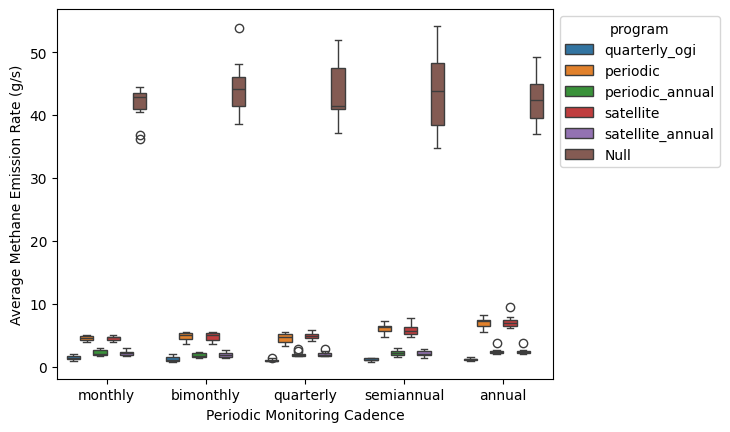

In [6]:
ax = sns.boxplot(data = looped_results[looped_results['threshold'] == 5], x = 'cadence', y = 'val_avg', hue = 'program')
ax.set(xlabel='Periodic Monitoring Cadence', ylabel='Average Methane Emission Rate (g/s)')
sns.move_legend(ax, 'upper left', bbox_to_anchor=(1,1))


Next plot: Same thing but with sum emissions

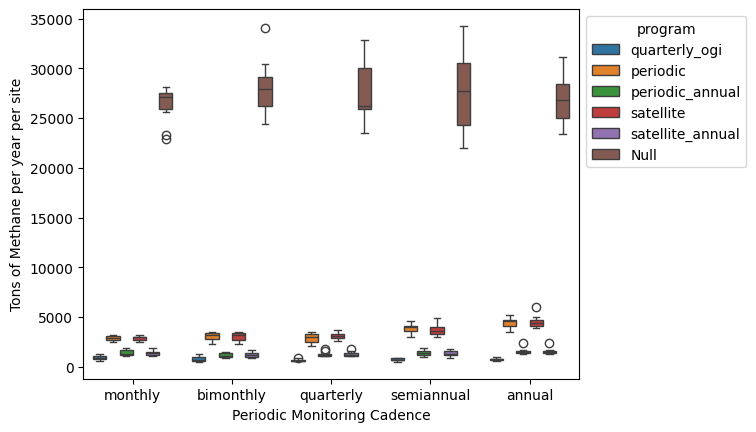

In [7]:
ax = sns.boxplot(data = looped_results[looped_results['threshold'] == 5], x = 'cadence', y = 'val_sum', hue = 'program')
ax.set(xlabel='Periodic Monitoring Cadence', ylabel='Tons of Methane per year per site')
sns.move_legend(ax, 'upper left', bbox_to_anchor=(1,1))

Facet out the plots by threshold; 

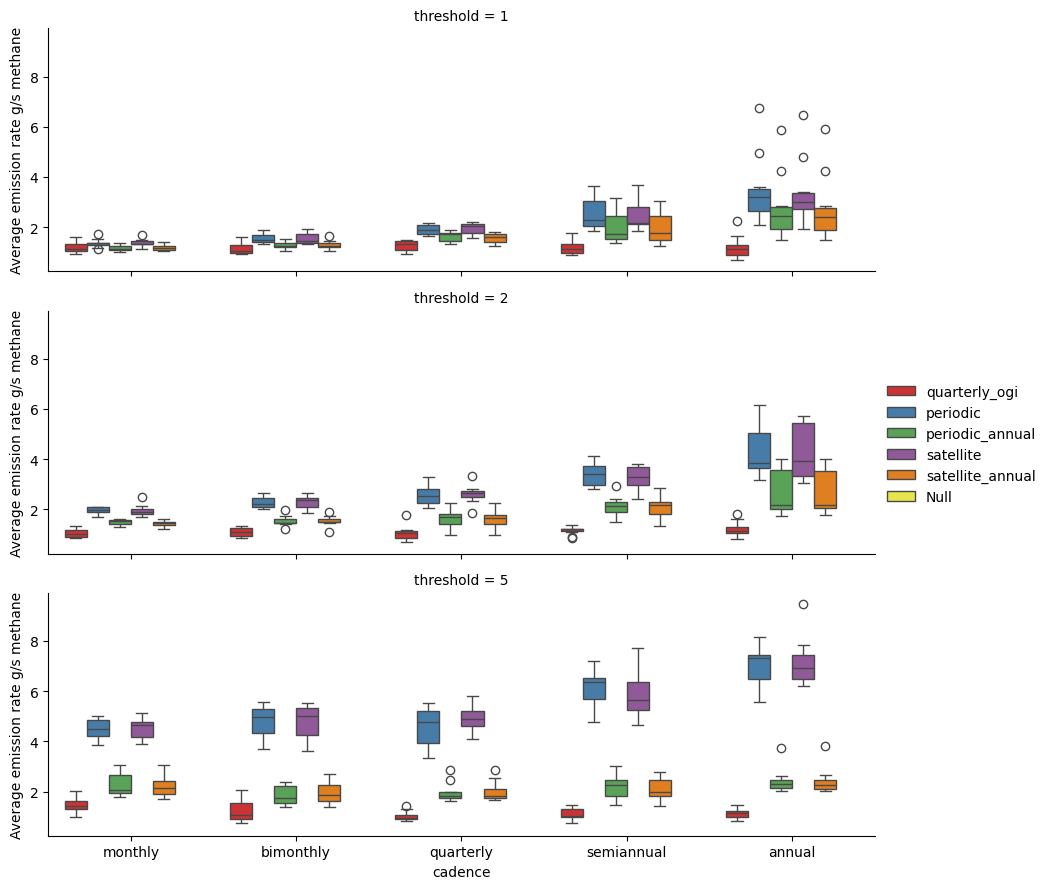

In [9]:
g = sns.FacetGrid(looped_results[looped_results['program'] != 'Null'], row = "threshold",  aspect = 3, height =3)
g.map_dataframe(sns.boxplot,  x = 'cadence', y = 'val_avg',  hue = 'program',palette='Set1' ).add_legend().set(ylabel='Average emission rate g/s methane')


Same thing as the sum: 

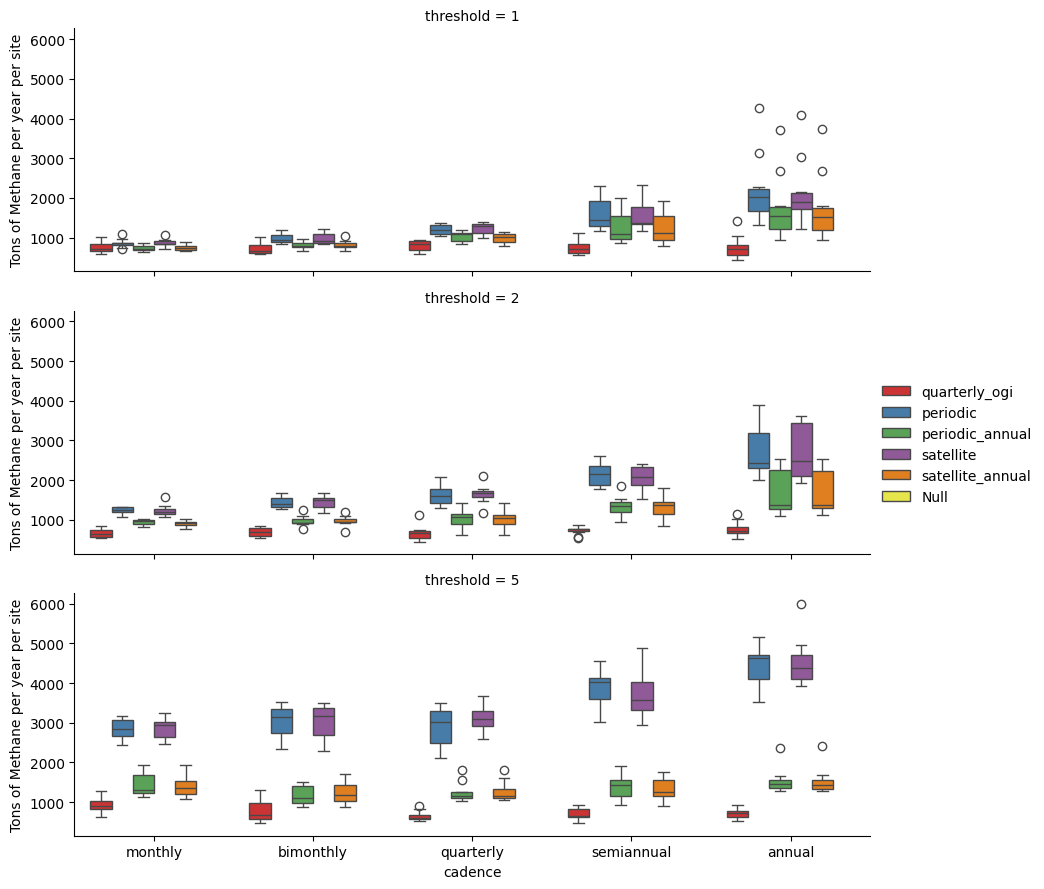

In [10]:
g = sns.FacetGrid(looped_results[looped_results['program'] != 'Null'], row = "threshold",  aspect = 3, height =3)
g.map_dataframe(sns.boxplot,  x = 'cadence', y = 'val_sum',  hue = 'program',palette='Set1' ).add_legend().set(ylabel='Tons of Methane per year per site')